In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.08605331733822823, 0.9723428571428572)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.2887528136909008, 0.9053)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.974967
automobile    0.986067
bird          0.967257
cat           0.943745
deer          0.973034
dog           0.946373
frog          0.984750
horse         0.974625
ship          0.988370
truck         0.983314
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 5, 2, 4]

In [17]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t in [6,4,7,2]):
                            indexT.append(idx.cpu().numpy().item()) 
                            
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        if(t in [6,4,7,2]):
                            indexF.append(idx.cpu().numpy().item()) 
                            
            torch.cuda.empty_cache() 
        return indexF,indexT

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('softmax',0.98)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(8823, 26177)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3255, 6745)

In [20]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [21]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [22]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [23]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F' or data_name=='F_f'or data_name=='T_f'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.38158118785449435,train_accu=0.8436857142857143
Epoch=0,valid_loss=0.36442214202880857,valid_accu=0.839
0
Epoch=1,train_loss=0.3584052421774183,train_accu=0.8453142857142857
Epoch=1,valid_loss=0.32123242564201354,valid_accu=0.864
0
Epoch=2,train_loss=0.3333875689779009,train_accu=0.8625142857142857
Epoch=2,valid_loss=0.32072436394691467,valid_accu=0.8571
Epoch=3,train_loss=0.323746873317446,train_accu=0.8663142857142857
Epoch=3,valid_loss=0.31923832516670225,valid_accu=0.8567
Epoch=4,train_loss=0.31600008839198523,train_accu=0.8702857142857143
Epoch=4,valid_loss=0.3226737081050873,valid_accu=0.8519
Epoch=5,train_loss=0.30733044615473065,train_accu=0.8741142857142857
Epoch=5,valid_loss=0.303759840297699,valid_accu=0.8659
0
Epoch=6,train_loss=0.3068884801796504,train_accu=0.8734857142857143
Epoch=6,valid_loss=0.30181223864555357,valid_accu=0.8686
0
Epoch=7,train_loss=0.3090371695688793,train_accu=0.8746285714285714
Epoch=7,valid_loss=0.2892822681427002,valid_accu=0.8

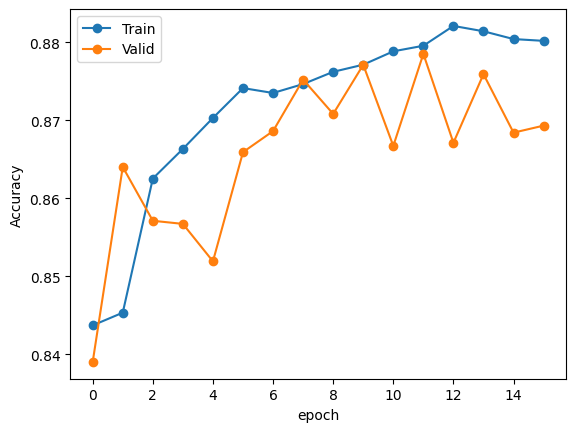

In [24]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70)

In [25]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.00898595546532064,train_accu=0.9972494938304619
Epoch=0,valid_loss=0.10189976852052118,valid_accu=0.9881393624907339
0
Epoch=1,train_loss=0.00825120867452941,train_accu=0.9978225159491156
Epoch=1,valid_loss=0.11790445834541405,valid_accu=0.9873980726464048
Epoch=2,train_loss=0.00666546547838214,train_accu=0.9982045306948848
Epoch=2,valid_loss=0.10433673873809525,valid_accu=0.9866567828020756
Epoch=3,train_loss=0.0024924592958342467,train_accu=0.9993505749321924
Epoch=3,valid_loss=0.11926789651069993,valid_accu=0.9881393624907339
Epoch=4,train_loss=0.0028842701874599386,train_accu=0.9993505749321924
Epoch=4,valid_loss=0.13046953601153724,valid_accu=0.9869532987398073
4 Early stopping!


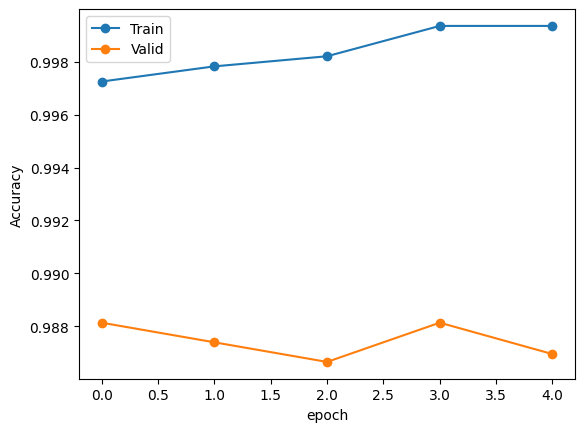

In [26]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.21418865190048977,train_accu=0.9323359401564094
Epoch=0,valid_loss=0.7419239444483626,valid_accu=0.7453149001536098
0
Epoch=1,train_loss=0.13615997378671843,train_accu=0.961010993992973
Epoch=1,valid_loss=0.7461102366447449,valid_accu=0.754531490015361
0
Epoch=2,train_loss=0.09755733103205202,train_accu=0.973705088972005
Epoch=2,valid_loss=0.7825202620157632,valid_accu=0.7529953917050691
Epoch=3,train_loss=0.06174924602844163,train_accu=0.9853791227473648
Epoch=3,valid_loss=0.7622541965610604,valid_accu=0.7560675883256528
0
Epoch=4,train_loss=0.04783180774028348,train_accu=0.9887793267596056
Epoch=4,valid_loss=0.7950696600930116,valid_accu=0.7619047619047619
0
Epoch=5,train_loss=0.033750604171017516,train_accu=0.9925195511730703
Epoch=5,valid_loss=0.8441268291890895,valid_accu=0.7517665130568356
Epoch=6,train_loss=0.026287935766129995,train_accu=0.9951263742491216
Epoch=6,valid_loss=0.8492947838822817,valid_accu=0.7557603686635944
Epoch=7,train_loss=0.0152403710279

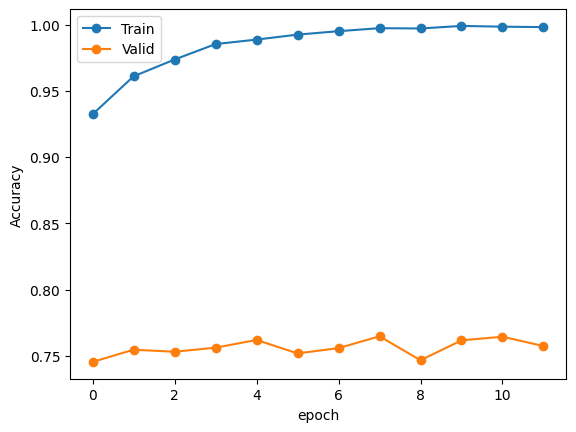

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.2898139055115836, 0.8831428571428571)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.28509437894821166, 0.8785)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.00922402046949848, 0.9974405012033465)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.015620955583888239, 0.9976198571914315)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.10435336778589177, 0.9881393624907339)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.8560911641142884, 0.7606758832565285)

In [35]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.011060811775038018, 0.9976285714285714)

In [36]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.35389836016371845, 0.9155, 3255)

In [37]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.021368113613444647, 0.9948571428571429, 11162, 23838)

In [38]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.36012608177810906, 0.913, 3629, 6371)

In [89]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [90]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=('softmax', 0.98)


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.086053,0.972343,0.288753,0.905300
1,Model_Decision,0.289814,0.883143,0.285094,0.878500
2,Model_T,0.009224,0.997441,0.104353,0.988139
3,Model_F,0.015621,0.997620,0.856091,0.760676
4,Total_Model,0.021368,0.994857,0.360126,0.913000
5,Total_Model_without_decision,0.011061,0.997629,0.353898,0.915500


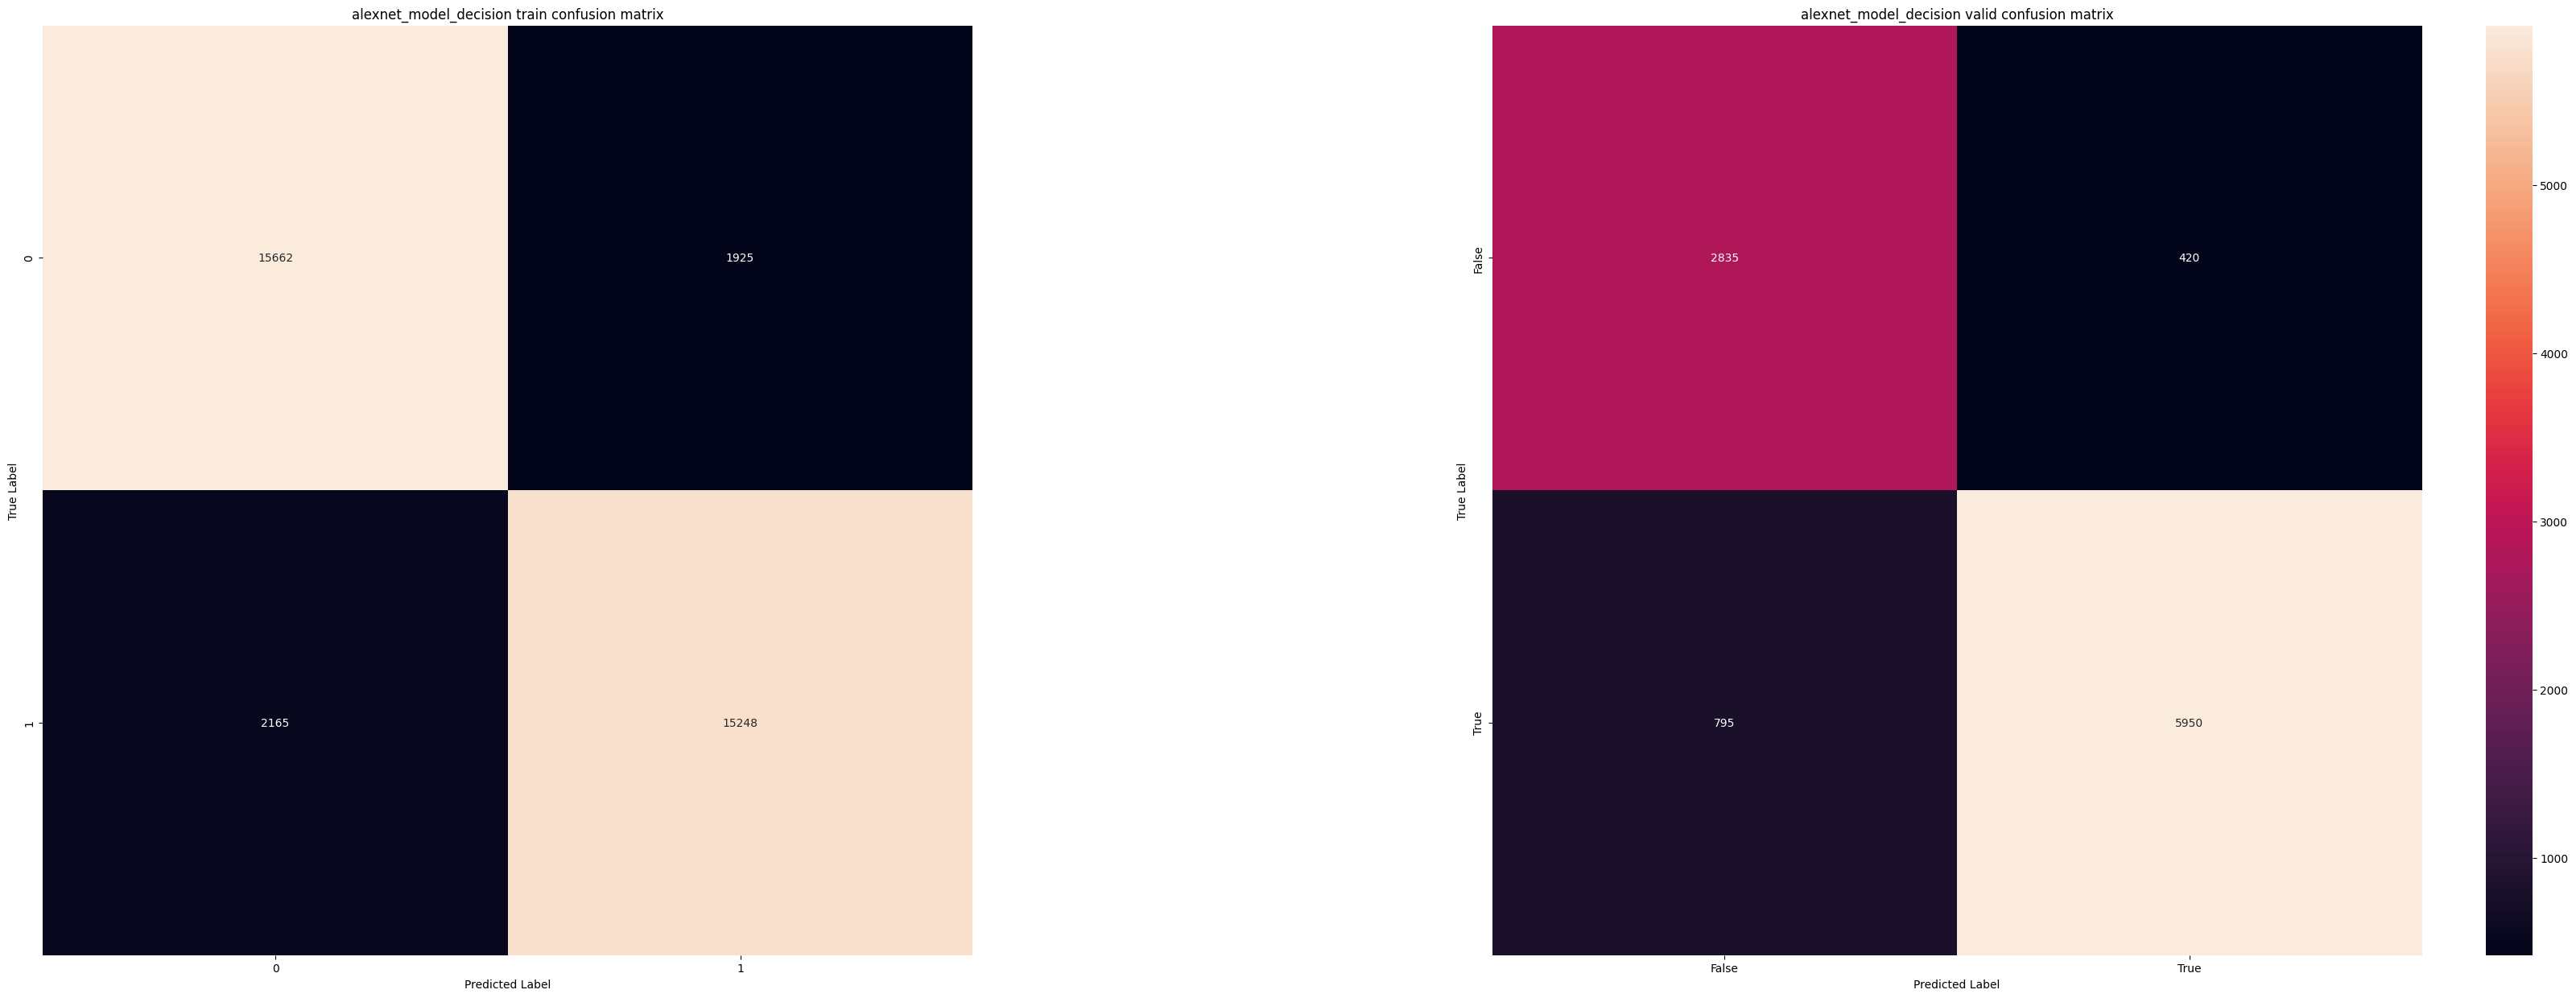

In [41]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

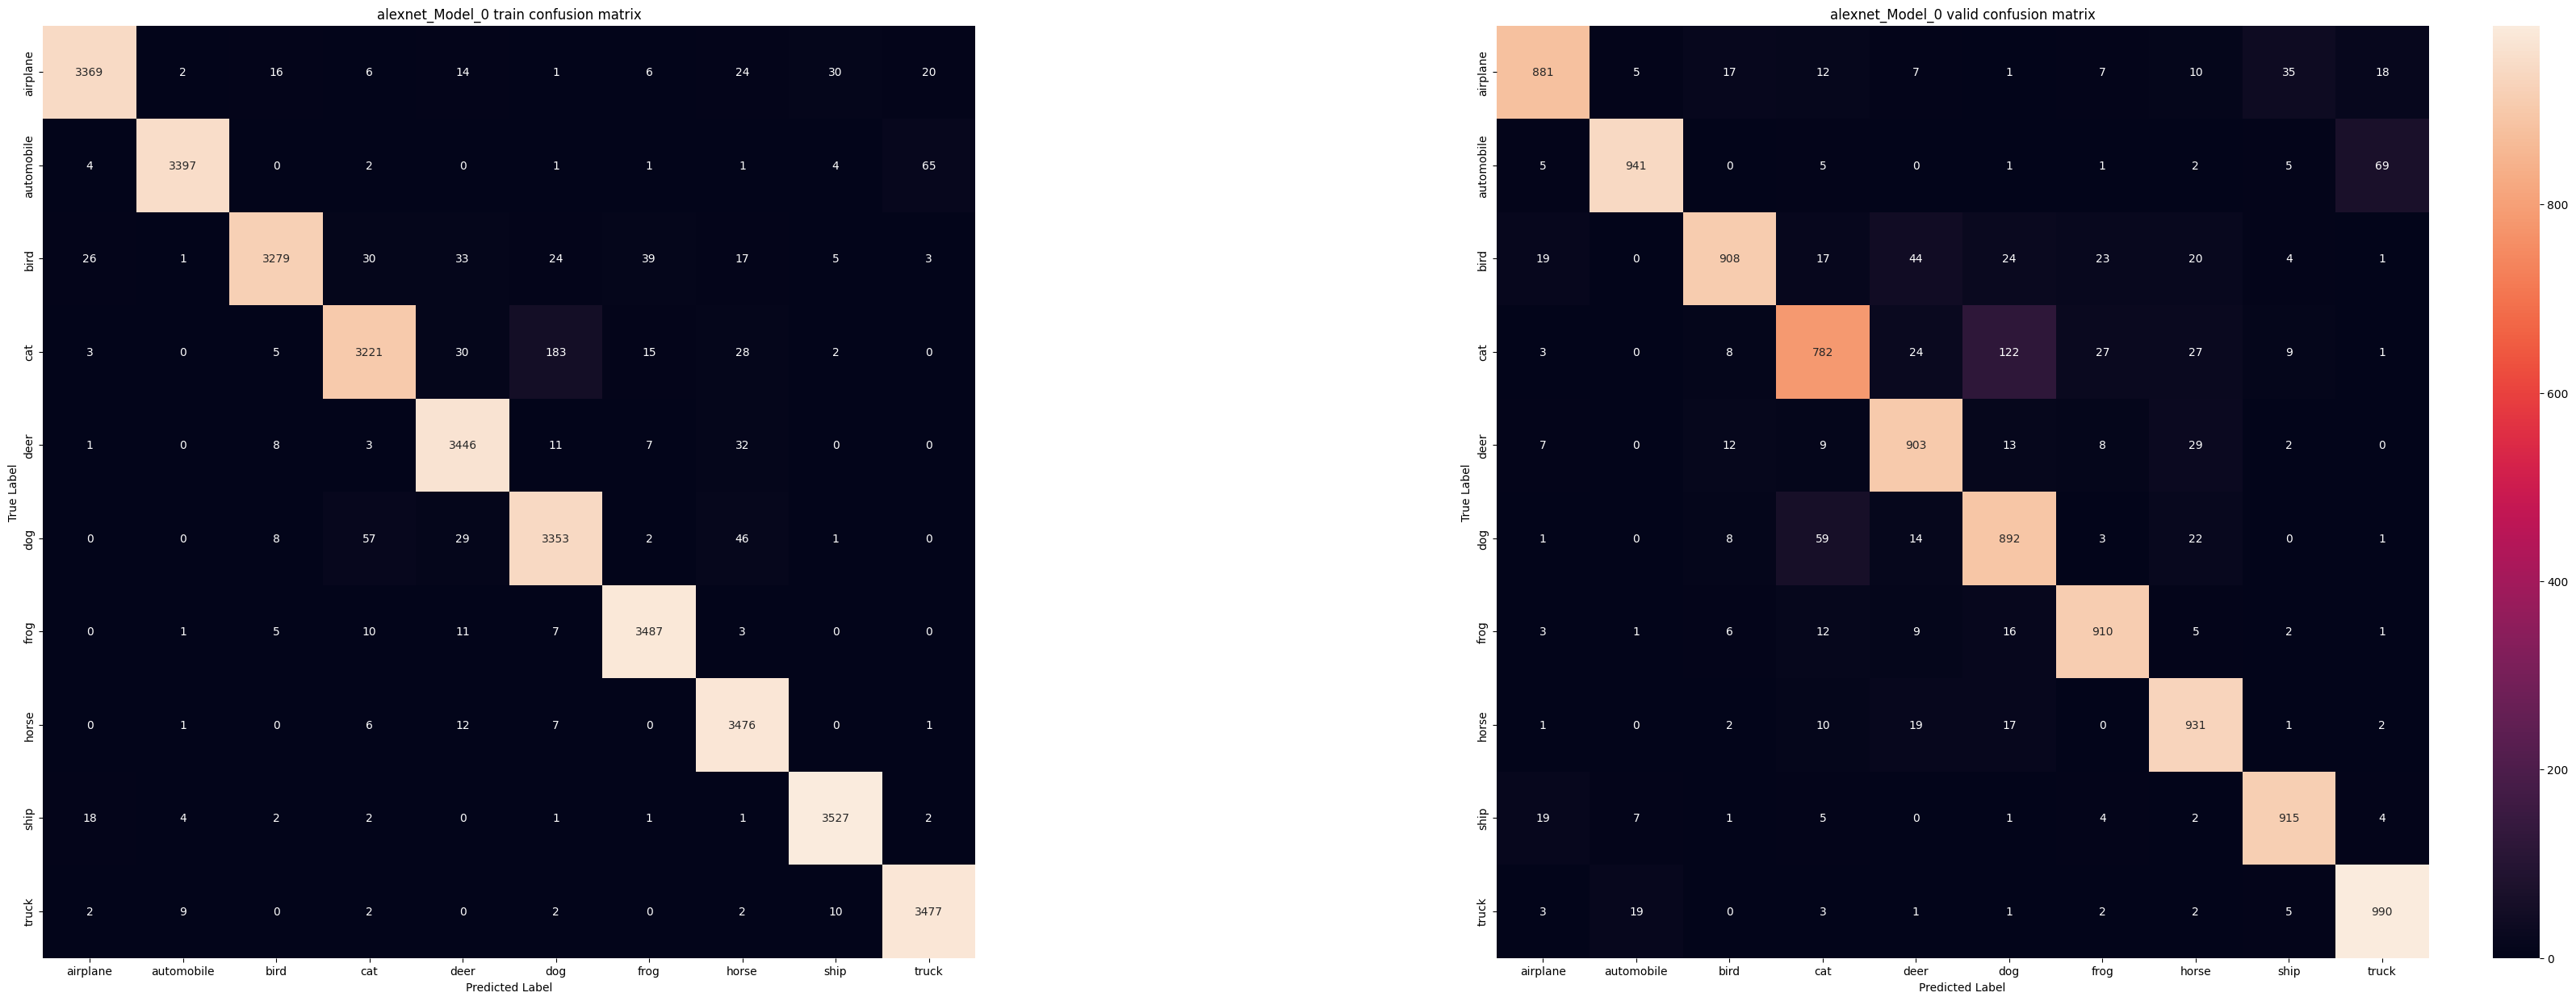

In [42]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [43]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [44]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.06878499 0.02127353 0.01515618 0.01365994 0.0127003  0.01254764
 0.01210813 0.01182635 0.01143088 0.01011194 0.00974264 0.00945857
 0.00923077 0.00713938 0.00688073]
Top 15 Positions:
[(5, 3), (9, 1), (7, 5), (8, 0), (6, 2), (7, 4), (2, 0), (4, 2), (5, 4), (3, 2), (7, 3), (4, 3), (5, 2), (6, 3), (7, 0)]


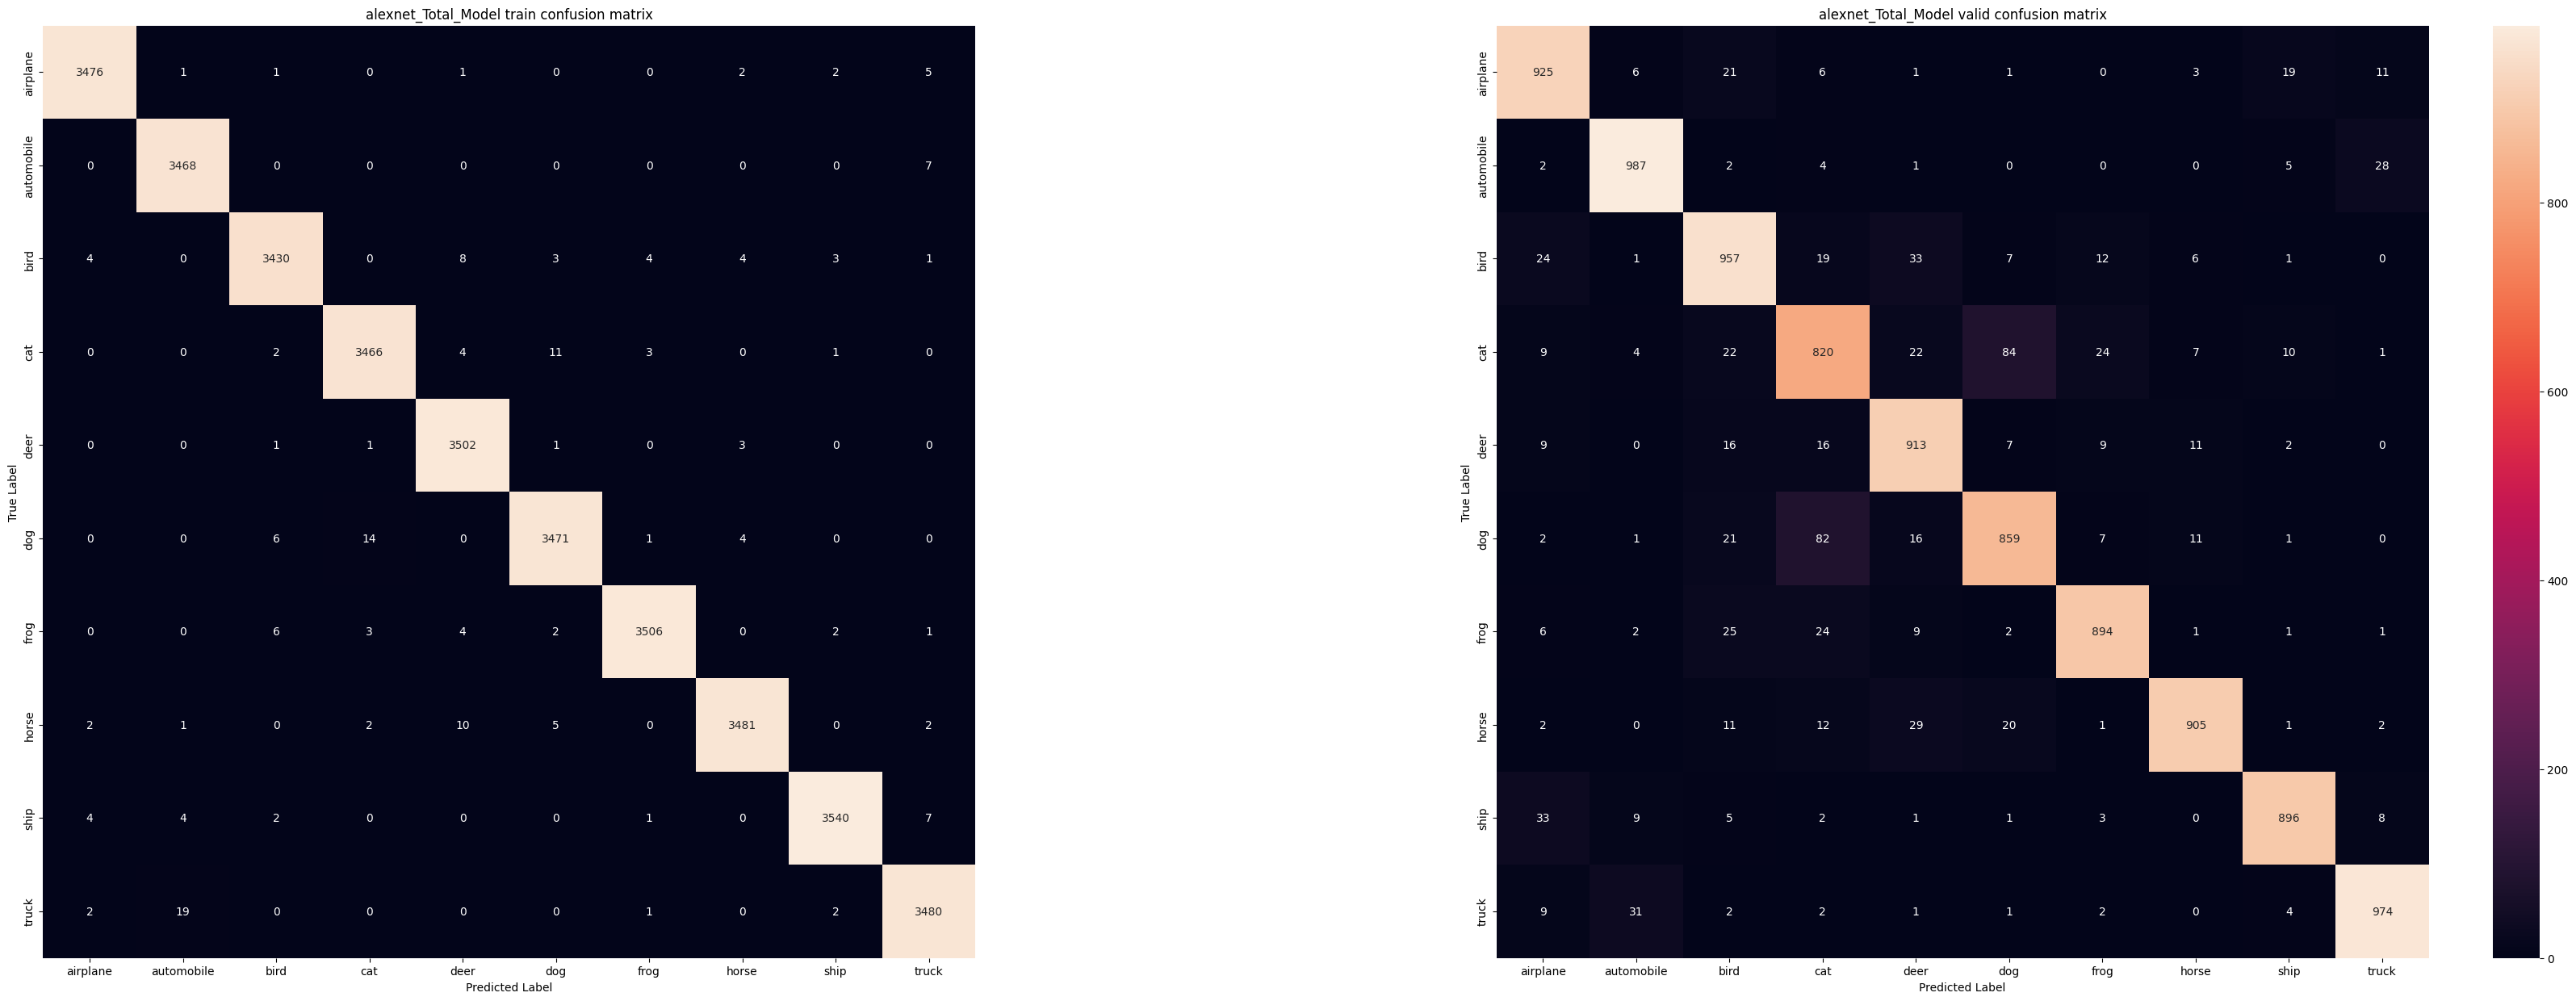

In [45]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

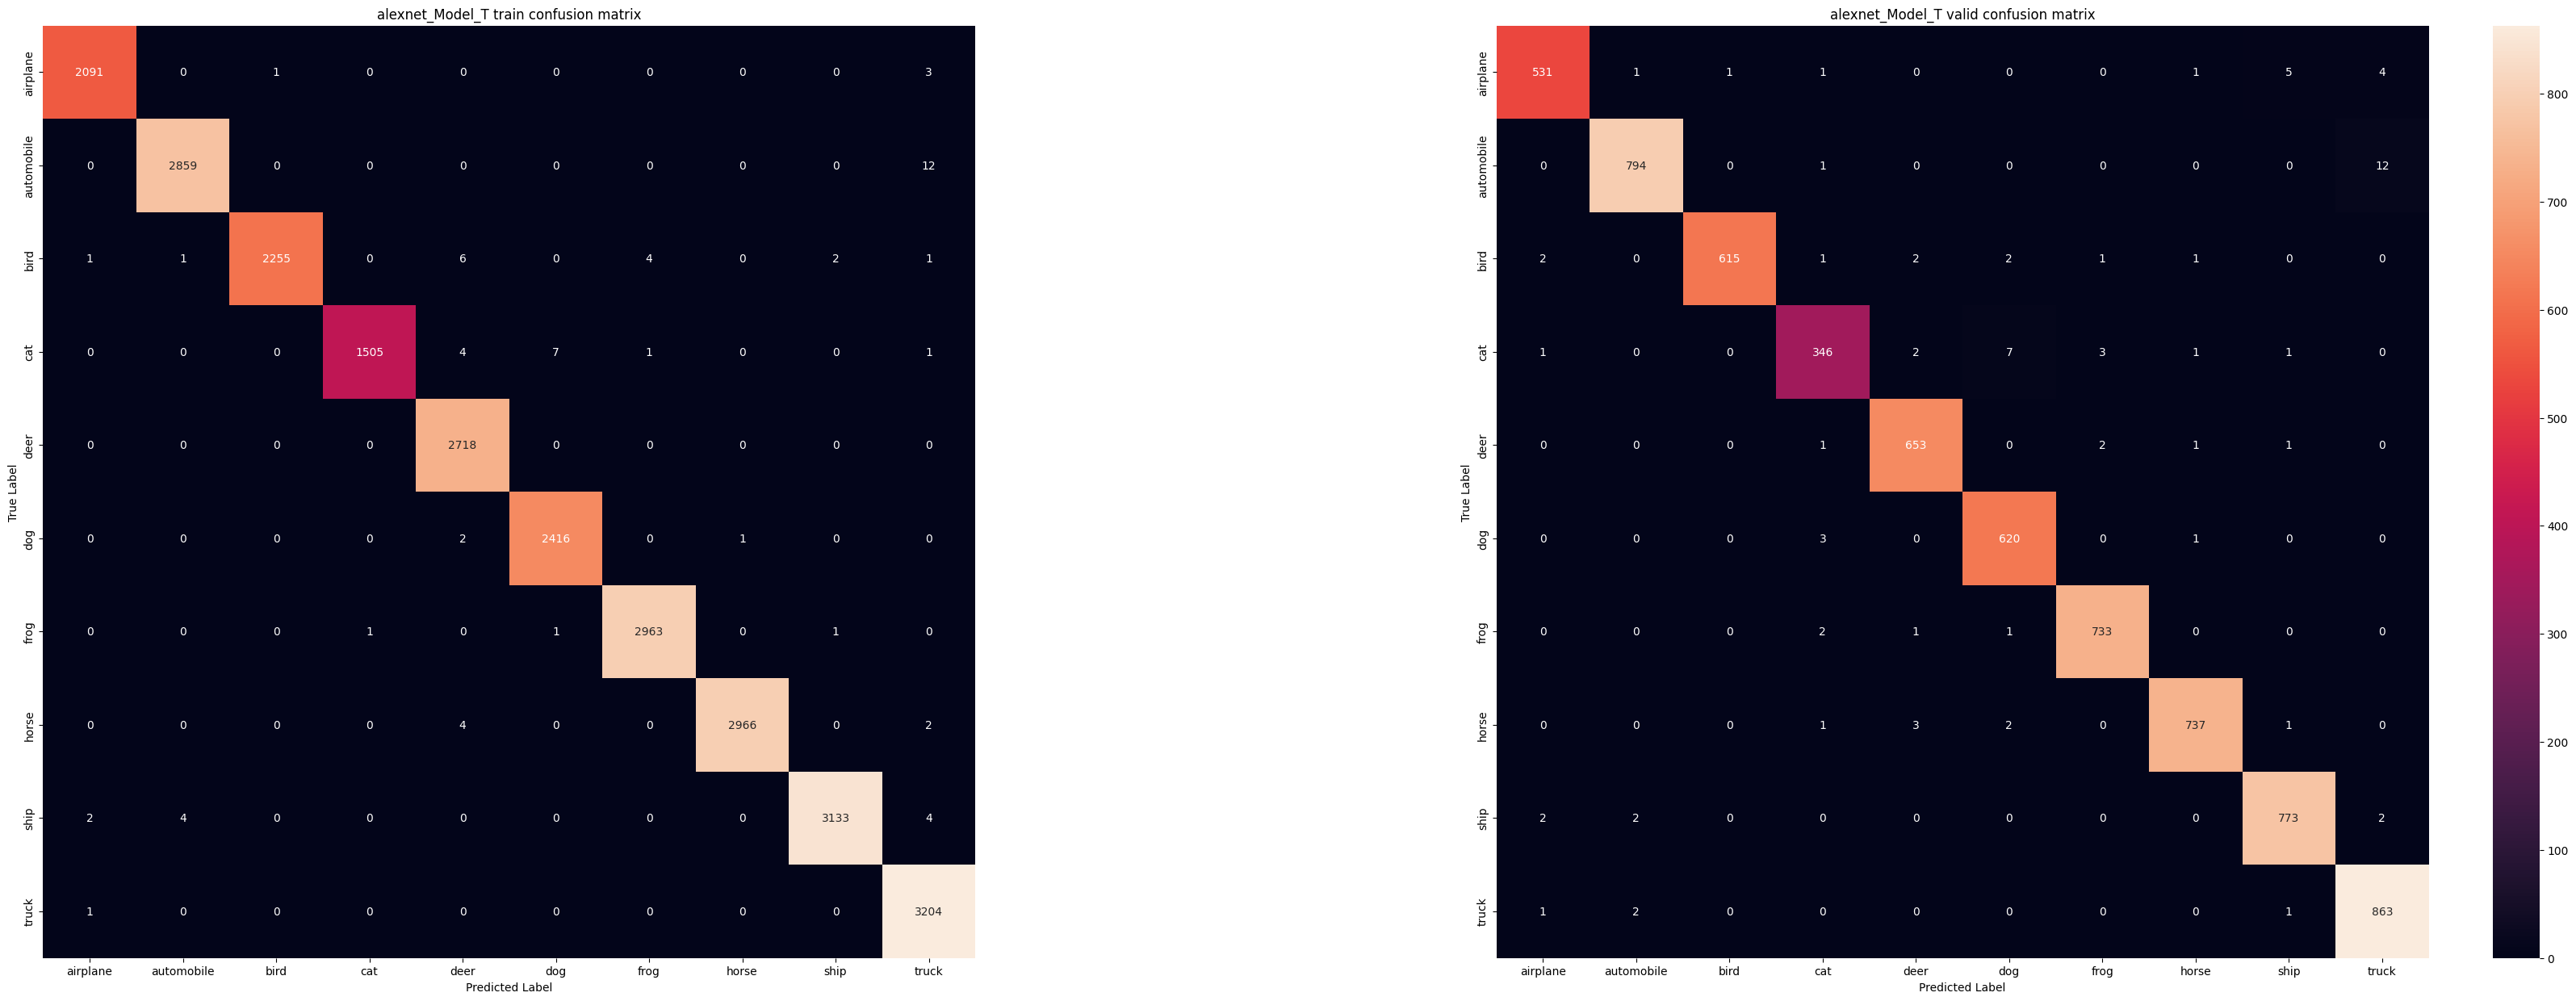

In [46]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

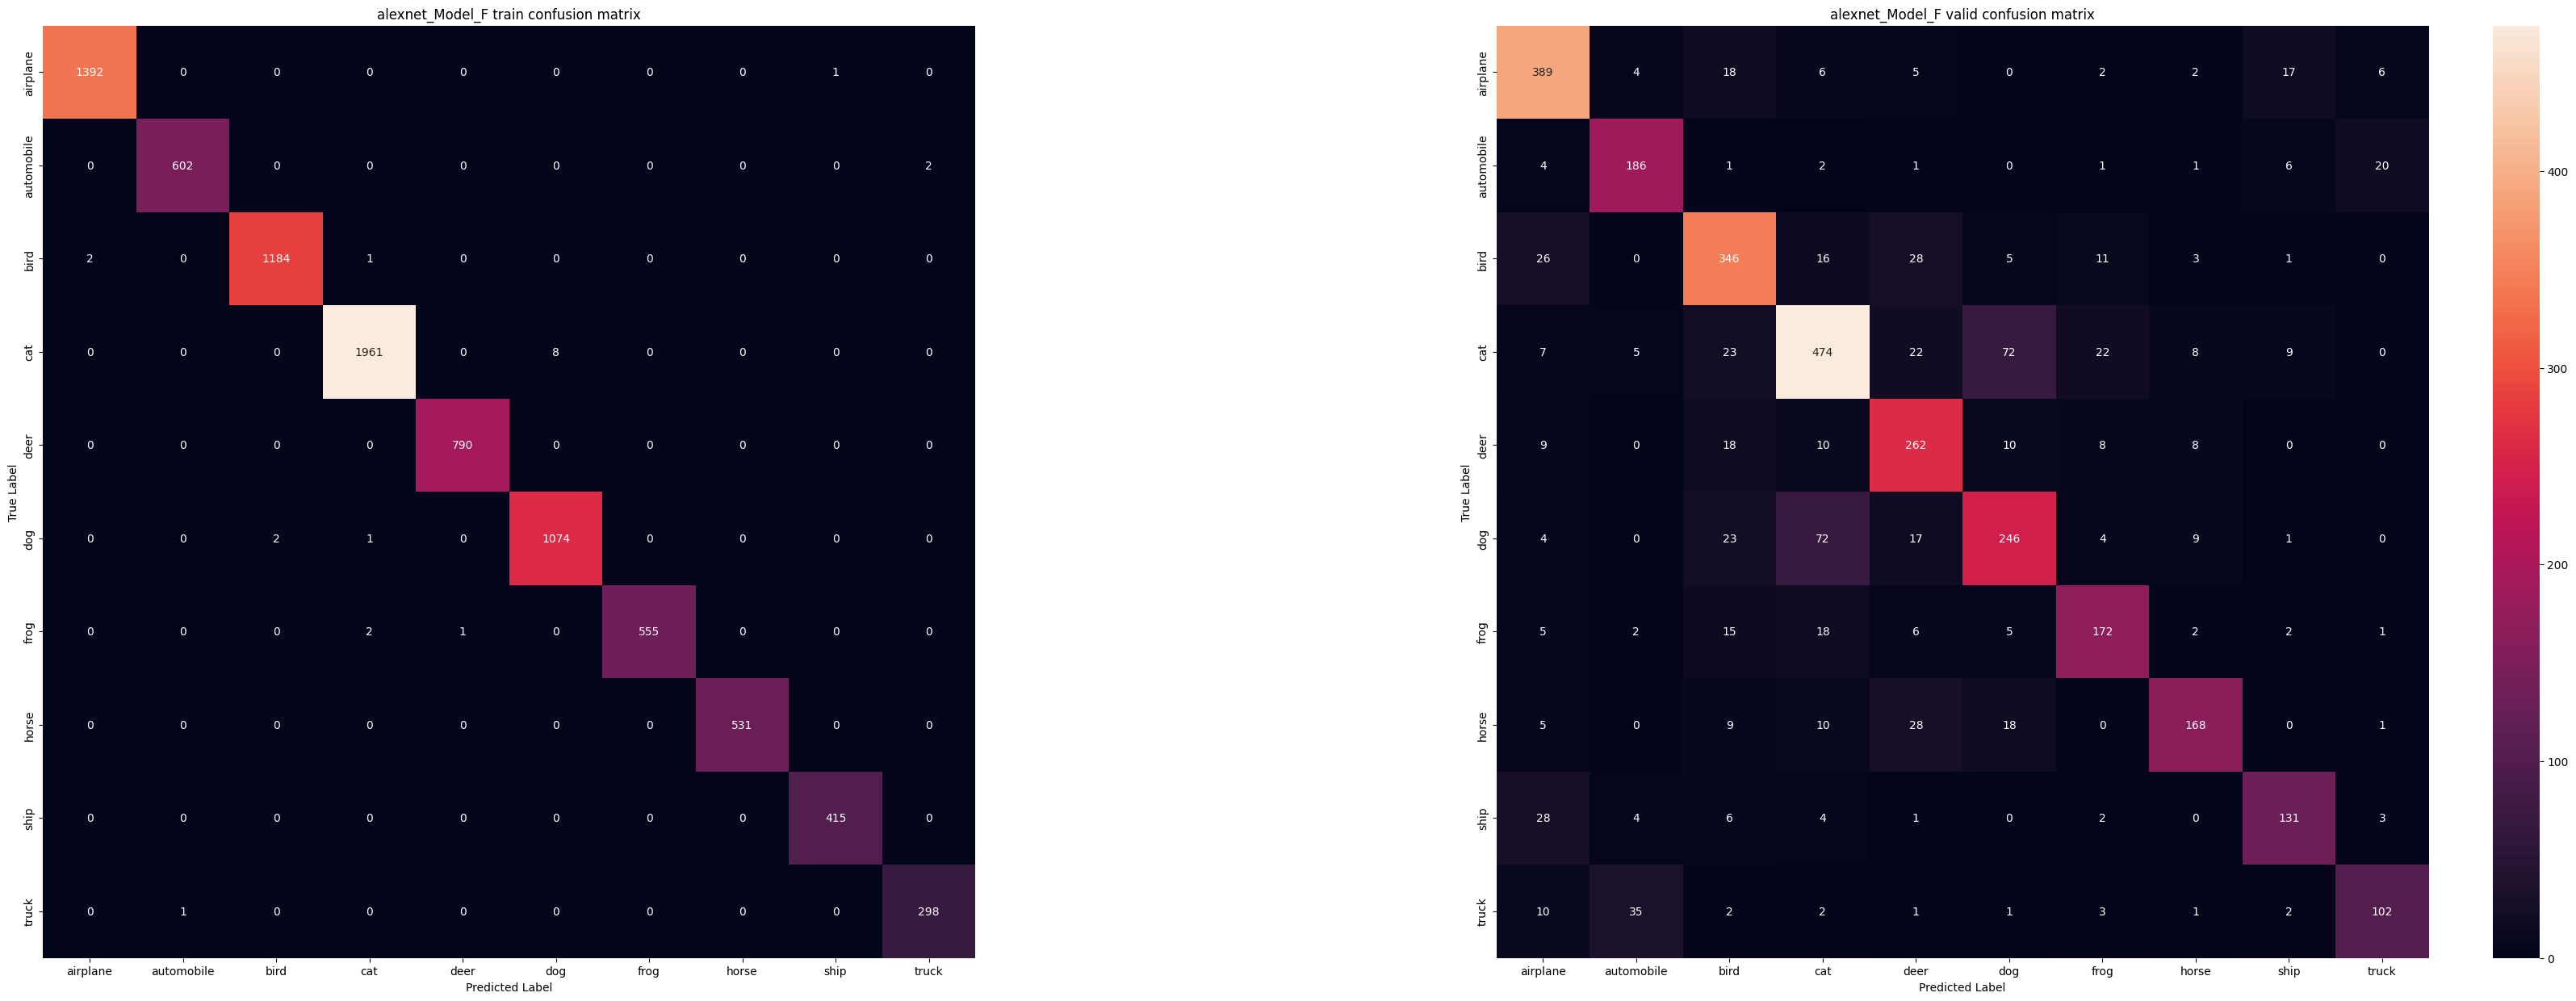

In [47]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [48]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [49]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,34786,6,6,6,6,0.999924,0.999995,0.999957,0.897547,True,True,True,True,True
1,14081,7,7,7,7,1.000000,1.000000,0.999999,0.999250,True,True,True,True,True
2,40950,3,3,3,3,0.999981,0.999998,0.993695,0.516393,True,True,True,False,True
3,43414,6,6,6,6,1.000000,1.000000,0.999988,0.996119,True,True,True,True,True
4,45868,8,8,8,8,1.000000,1.000000,1.000000,0.999920,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,637,0,0,0,0,1.000000,1.000000,0.999448,0.902920,True,True,True,True,True
34996,29686,7,7,7,7,1.000000,0.999996,0.999919,0.980740,True,True,True,True,True
34997,41720,5,5,5,5,1.000000,1.000000,1.000000,0.999999,True,True,True,True,True
34998,41914,3,3,3,3,0.999610,0.967089,0.912963,0.972962,True,True,True,False,False


In [50]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
2,40950,3,3,3,3,0.999981,0.999998,0.993695,0.516393,True,True,True,False,True
8,1211,0,0,0,0,0.999902,0.888739,0.892749,0.501517,True,True,True,True,False
12,42133,3,3,3,3,0.999783,0.999609,0.988126,0.657992,True,True,True,False,True
14,44838,5,5,5,5,0.999967,0.999983,0.998846,0.935180,True,True,True,True,False
21,32341,0,0,0,0,0.999972,0.999793,0.989328,0.676079,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34954,8586,5,5,5,5,0.990402,0.998326,0.971748,0.713705,True,True,True,False,True
34973,24898,7,7,7,7,0.997259,0.996431,0.982673,0.787796,True,True,True,False,True
34983,17441,3,3,3,3,0.999995,0.999954,0.999355,0.683764,True,True,True,False,True
34989,29568,6,6,6,6,0.999957,0.999896,0.994436,0.634934,True,True,True,True,False


In [51]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

3    724
2    636
0    567
4    511
5    441
7    363
6    346
1    329
8    285
9    240
Name: Target, dtype: int64

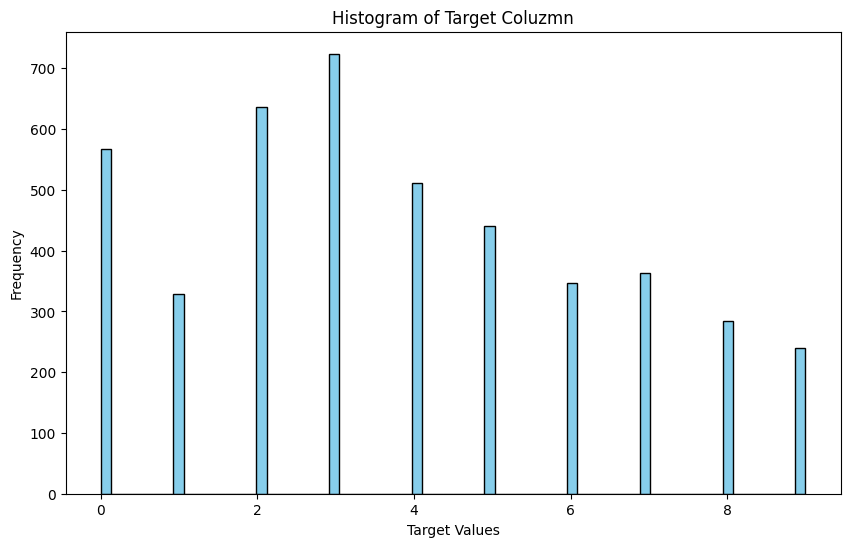

In [52]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [53]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,18812,8,8,8,8,1.000000,1.000000,1.000000,0.999721,True,True,True,True,True
1,38762,4,6,6,6,0.963195,0.982690,0.797834,0.818275,False,False,False,False,False
2,15174,8,8,8,8,0.999960,0.999995,0.999886,0.951454,True,True,True,True,True
3,28212,0,0,0,0,1.000000,1.000000,0.999999,0.999118,True,True,True,True,True
4,46304,1,1,1,1,0.999979,0.999488,0.997535,0.590724,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,32889,5,7,7,7,0.507930,0.569208,0.975732,0.566989,False,False,False,False,False
9996,14316,4,4,4,4,1.000000,1.000000,0.999941,0.922925,True,True,True,True,True
9997,12179,4,4,4,4,0.935207,0.999965,0.996414,0.718122,True,True,True,True,True
9998,5538,7,7,7,7,0.839204,0.899089,0.930772,0.824467,True,True,True,False,False


In [54]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,479,3,3,3,3,0.999945,0.999964,0.990320,0.879265,True,True,True,False,True
37,17988,6,6,6,6,0.999778,0.999936,0.998319,0.866677,True,True,True,False,True
50,8815,6,6,6,6,0.999135,0.998469,0.992583,0.785634,True,True,True,True,False
55,45854,3,3,3,3,0.971132,0.996121,0.984798,0.822971,True,True,True,False,True
58,9232,1,9,9,9,0.990502,1.000000,0.997603,0.646667,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,26542,6,6,6,6,0.997557,0.992961,0.978898,0.773084,True,True,True,False,True
9975,33592,7,7,7,7,0.946747,0.982483,0.985609,0.934519,True,True,True,False,True
9985,224,6,6,6,6,0.994800,0.992432,0.931469,0.576738,True,True,True,True,False
9989,43948,1,1,1,1,0.998680,0.992470,0.797671,0.828448,True,True,True,False,True


In [55]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

2    184
0    160
3    150
4    135
7    128
5    116
6     98
9     84
1     76
8     75
Name: Target, dtype: int64

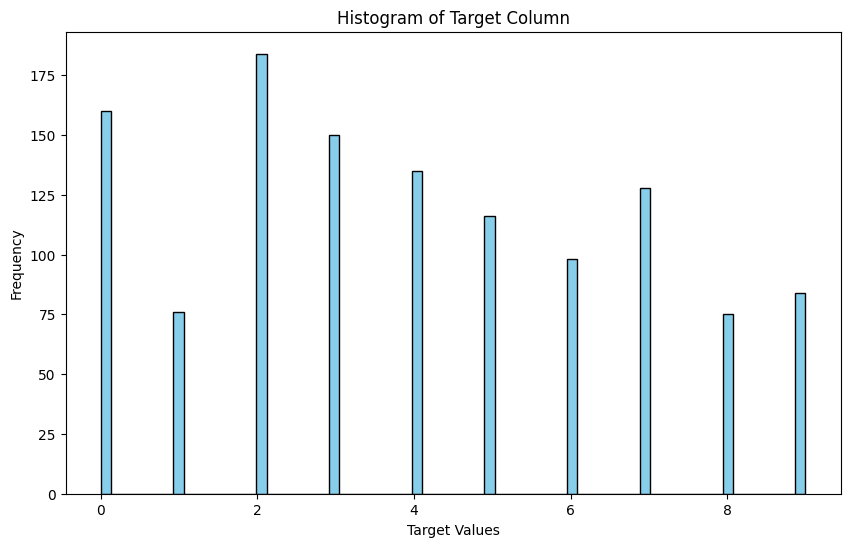

In [56]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [57]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [58]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.020883509844564833, 0.9955428571428572, 11188, 23812)

In [59]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.3832777841836214, 0.9152, 3431, 6569)

In [60]:
ALL=set(range(10))
targetT=list(ALL-set(targetF))

model_0_embed= copy.deepcopy(model_0)
# model_0_embed.classifier[5]=nn.Identity()
model_0_embed.classifier[6]=nn.Identity()

In [61]:
mean_features_dict_T = {class_idx: [] for class_idx in targetT}
for data, target, idx in Tdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx not in  targetF:
                mean_features_dict_T[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_T = {}
for class_idx, features_list in mean_features_dict_T.items():
    mean_features_T[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [62]:
mean_features_dict_F = {class_idx: [] for class_idx in targetF}
for data, target, idx in Fdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx in targetF:
                mean_features_dict_F[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_F = {}
for class_idx, features_list in mean_features_dict_F.items():
    mean_features_F[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [63]:
mean_features_F

{3: tensor([0.0012, 0.1006, 0.0000,  ..., 0.1994, 0.0237, 0.0008]),
 5: tensor([0.0013, 0.1700, 0.0000,  ..., 0.5224, 0.0092, 0.0000]),
 2: tensor([0.0025, 0.1570, 0.0000,  ..., 0.0216, 0.0473, 0.0005]),
 4: tensor([0.0000, 0.0019, 0.0000,  ..., 0.0168, 0.0191, 0.0000])}

In [64]:
import torch.nn.functional as F
def calculate_sim_max_idx(f,mean_features):
    k=0
    max=0
    for i in mean_features.keys():
        sim=F.cosine_similarity(f,mean_features[i], dim=0)
        if(max<sim):
            k=i
            max=sim
    return k,max

In [65]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/train_size
sum_all

0.9852571428571428

In [66]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/valid_size
sum_all

0.9612

In [67]:
#全部模型裝在一起的表現
def total_model_cos_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
                k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)

                if(similarity_T>similarity_F):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [68]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.06795158873789811, 0.982, 14039, 20961)

In [69]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.399496173030138, 0.9036, 4068, 5932)

In [70]:
def choose_with_model(data):
    out_decision=model_decision(data)
    _, pred = torch.max(out_decision, dim = 1) 
    softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
    if(pred==0):
        return 0
    else:
        return 1

In [71]:
def choose_with_softmax(data):
    out_T = model_T(data)
    softmax_T=torch.softmax(out_T, dim=1)

    out_F = model_F(data)
    softmax_F=torch.softmax(out_F, dim=1)

    st_max=torch.max(softmax_T).item()
    sf_max=torch.max(softmax_F).item()

    if(sf_max>st_max):
        return 0
    else:
        return 1

In [72]:
def choose_with_sim(out,mean_features_T,mean_features_F):
    k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
    k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)
    if(similarity_T>similarity_F):
        return 1
    else:
        return 0


In [73]:
#全部模型裝在一起的表現
def total_model_decision_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
                soft_decision=choose_with_softmax(d.unsqueeze(0))
                mo_decision=choose_with_model(d.unsqueeze(0))
                total_decision=sim_decision+soft_decision+mo_decision

                if(total_decision>=2):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [74]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.033203530014073473, 0.9938, 12372, 22628)

In [75]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.3987478403538465, 0.9134, 3562, 6438)

In [76]:
# 计算并打印每个数据点的平均边际效应
def calculate_ame_per_sample(model, data_loader, delta=1e-5):
    model.eval()
    ames = []
    idxs=[]
    with torch.no_grad():
        for inputs, _,idx in data_loader:
            inputs = inputs.to(device)
            base_preds = model(inputs).cpu().numpy()

            batch_ames = []
            
            for i in range(inputs.shape[1]):  # 对每个通道计算边际效应
                inputs_delta = inputs.clone()
                inputs_delta[:, i, :, :] += delta
                delta_preds = model(inputs_delta).cpu().numpy()
                ame = (delta_preds - base_preds) / delta
                batch_ames.append(ame)

            batch_ames = np.stack(batch_ames, axis=1)  # (batch_size, num_channels, num_classes)
            batch_ames = np.mean(batch_ames, axis=(1, 2))
            
            ames.append(batch_ames)
            idxs.extend(idx.cpu().numpy())

    ames = np.concatenate(ames, axis=0)  # (num_samples, num_channels, num_classes)
    return idxs,ames



In [77]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_F, Fdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.95 # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Fdataset = Subset(images, filter_idxs)
filtered_Fdl= DataLoader(filtered_Fdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.20613713098260755,train_accu=0.9356878654098556
Epoch=0,valid_loss=0.7317110833484456,valid_accu=0.7483870967741936
0
Epoch=1,train_loss=0.13069480610105733,train_accu=0.9642047488366543
Epoch=1,valid_loss=0.7116326666098036,valid_accu=0.7646697388632873
0
Epoch=2,train_loss=0.09071431191905474,train_accu=0.9770910392554588
Epoch=2,valid_loss=0.7422071408932477,valid_accu=0.7619047619047619
Epoch=3,train_loss=0.06606396703291122,train_accu=0.985562582030784
Epoch=3,valid_loss=0.7841026396017103,valid_accu=0.759447004608295
Epoch=4,train_loss=0.04333200457627784,train_accu=0.9902159646820189
Epoch=4,valid_loss=0.8057519427825413,valid_accu=0.7711213517665131
0
Epoch=5,train_loss=0.0445375519129806,train_accu=0.9871137095811956
Epoch=5,valid_loss=0.8645504295917517,valid_accu=0.7542242703533026
Epoch=6,train_loss=0.023338818981089637,train_accu=0.9955852523565207
Epoch=6,valid_loss=0.8618249267477044,valid_accu=0.765284178187404
Epoch=7,train_loss=0.01742099865412259

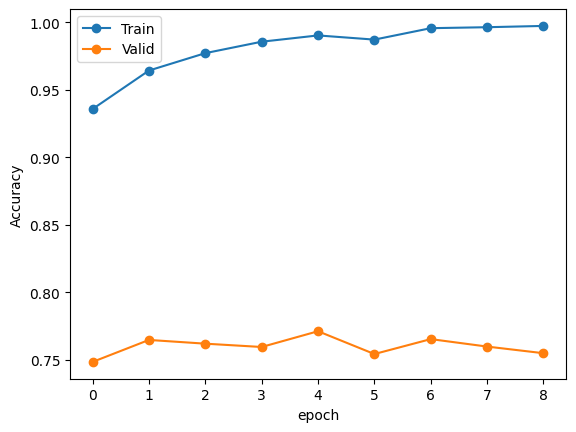

In [78]:
model_F_filter=model_train(model_algo,filtered_Fdl,Fdl_v,"F_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [79]:
# 计算并打印平均边际效应
idxs,ames = calculate_ame_per_sample(model_T, Tdl)
sorted_indices = np.argsort(ames)[::-1]  # 从大到小排序
sorted_indices
keep_ratio = 0.9  # 保留50%的数据点
num_keep = int(len(sorted_indices) * keep_ratio)
filtered_indices = sorted_indices[:num_keep]
filter_idxs=[]
for i in filtered_indices:
    filter_idxs.append(idxs[i])
    
# 重新加载和预处理训练数据集，使用剔除后的数据点
filtered_Tdataset = Subset(images, filter_idxs)
filtered_Tdl= DataLoader(filtered_Tdataset, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.00924567636960463,train_accu=0.9975380958444756
Epoch=0,valid_loss=0.10542074503740004,valid_accu=0.9871015567086731
0
Epoch=1,train_loss=0.007837986000916536,train_accu=0.9975805424678467
Epoch=1,valid_loss=0.1007334431305954,valid_accu=0.9876945885841364
0
Epoch=2,train_loss=0.003031298061541949,train_accu=0.9989388344157222
Epoch=2,valid_loss=0.10916672754896849,valid_accu=0.9878428465530023
0
Epoch=3,train_loss=0.002449214775566744,train_accu=0.99923596077932
Epoch=3,valid_loss=0.11863458403857118,valid_accu=0.9875463306152705
Epoch=4,train_loss=0.006535453350176369,train_accu=0.9980474553249289
Epoch=4,valid_loss=0.15528139327665008,valid_accu=0.9848776871756857
Epoch=5,train_loss=0.0032159568236517864,train_accu=0.9988963877923511
Epoch=5,valid_loss=0.1254235938062687,valid_accu=0.9876945885841364
Epoch=6,train_loss=0.0015702209235998017,train_accu=0.9994906405195467
Epoch=6,valid_loss=0.14667660894710263,valid_accu=0.9881393624907339
0
Epoch=7,train_loss=0.0

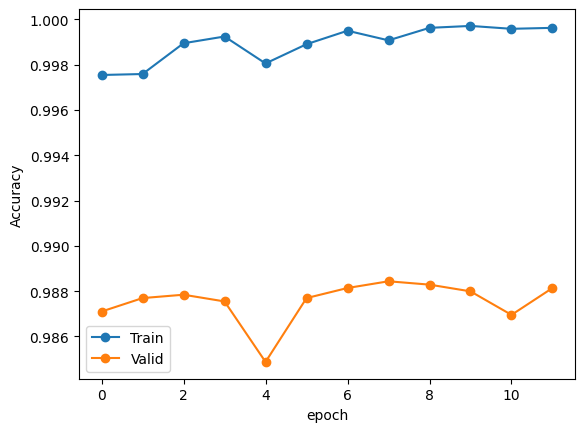

In [80]:
model_T_filter=model_train(model_algo,filtered_Tdl,Tdl_v,"T_f",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [81]:
F_loss_f,F_accu_f,confusion_matrix_F_train_f=evaluate_model(model_F_filter,Fdl,len(Fdataset),'F',mode='eval')
F_valid_loss_f,F_valid_accu_f,confusion_matrix_F_valid_f=evaluate_model(model_F_filter,Fdl_v,len(Fdataset_v),'F',mode='eval')

In [82]:
T_loss_f,T_accu_f,confusion_matrix_T_train_f=evaluate_model(model_T_filter,Tdl,len(Tdataset),'T',mode='eval')
T_valid_loss_f,T_valid_accu_f,confusion_matrix_T_valid_f=evaluate_model(model_T_filter,Tdl_v,len(Tdataset_v),'T',mode='eval')

In [83]:
total_train_loss_f,total_train_accu_f,confusion_matrix_total_train_f,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T_filter,model_F_filter,model_decision)
total_valid_loss_f,total_valid_accu_f,confusion_matrix_total_valid_f,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T_filter,model_F_filter,model_decision)

In [84]:
train_losses=[train_loss,decision_loss,T_loss_f,F_loss_f,total_train_loss_f,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu_f,F_accu_f,total_train_accu_f,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss_f,F_valid_loss_f,total_valid_loss_f,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu_f,F_valid_accu_f,total_valid_accu_f,total_valid_accu_d]

In [85]:
model_algos=['Model_0','Model_Decision',"Model_T_f","Model_F_f","Total_Model_f",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'targetF={targetF}')
df

targetF=[3, 5, 2, 4]


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.086053,0.972343,0.288753,0.905300
1,Model_Decision,0.289814,0.883143,0.285094,0.878500
2,Model_T_f,0.002606,0.999045,0.146567,0.986953
3,Model_F_f,0.053151,0.986399,0.799186,0.771736
4,Total_Model_f,0.031712,0.992371,0.383930,0.915000
5,Total_Model_without_decision,0.011061,0.997629,0.353898,0.915500
